In [1]:
# import classy module
from classy import Class

In [2]:
# create instance of the class "Class"
LambdaCDM = Class()
# pass input parameters
# LambdaCDM.set({'omega_b':0.0223828,'omega_cdm':0.1201075,'h':0.67810,'A_s':2.100549e-09,'n_s':0.9660499,'tau_reio':0.05430842})
LambdaCDM.set({'omega_b':0.02237,'omega_cdm':0.1200,'h':0.6736,'A_s':2.0830e-9,'n_s':0.9649,'tau_reio':0.0568, 'k_pivot': 0.05, 'N_ur':3.046, 'T_cmb': 2.7255})
LambdaCDM.set({'output':'mPk','lensing':'no','P_k_max_1/Mpc':3.0, 'z_max_pk': 1.0})

# run class
LambdaCDM.compute()

# get reduced Hubble for conversions to 1/Mpc
h = LambdaCDM.h()
print(h)

0.6736


In [3]:
# uncomment to get plots displayed in notebook
%matplotlib inline
import matplotlib.pyplot as plt
from math import pi
from matplotlib import rc
from matplotlib import rcParams
from matplotlib.gridspec import GridSpec
import numpy as np
from plotting_utils import plot_segments
import pandas as pd


# Mathematica directory
dir = "/Users/fynn/Desktop/Uni/Master/Masters-thesis/04 Mathematica"

# Enable LaTeX rendering
rcParams['figure.dpi'] = 120
rc('text', usetex=False)
rc('font', family='serif', size=15)

rcParams.update({
    'font.size': 15,
    'axes.titlesize': 15,
    'axes.labelsize': 15,
    'xtick.labelsize': 15,
    'ytick.labelsize': 15,
    'legend.fontsize': 15,
})

def compare_integrals(x1, x2, y1real, y1imag, y2real, y2imag, ylabel):
    factor_real = np.mean(y1real/y2real)
    factor_imag = np.mean(y1imag/y2imag)
    print("factor=", factor_real, factor_imag)


    residuals_real = 100 * (y1real-y2real)/y1real
    residuals_imag = 100 * (y1imag-y2imag)/y1imag

    fig = plt.figure(figsize=(8, 6))
    gs = GridSpec(2, 1, height_ratios=[3, 1], hspace=0.1)

    # Main plot (data + fit)
    ax1 = fig.add_subplot(gs[0])
    ax1.plot(x1, np.abs(y1real), label="real analytical")
    ax1.plot(x2, np.abs(y2real), ls="--", label="real mathematica numerical")
    ax1.plot(x1, np.abs(y1imag), label="imag analytical")
    ax1.plot(x2, np.abs(y2imag), ls="--", label="imag mathematica numerical")
    ax1.set_yscale("log")
    ax1.set_ylabel(rf"{ylabel}")
    ax1.legend()
    ax1.grid()
    ax1.tick_params(labelbottom=False)  # Hide x-axis labels for top plot

    # Residual plot (same x-axis)
    ax2 = fig.add_subplot(gs[1], sharex=ax1)  # Shares x-axis with ax1
    ax2.axhline(0, color='black', linestyle='--', linewidth=1)
    ax2.plot(x1, residuals_real, color='black', label="Residuals Real")
    ax2.plot(x1, residuals_imag, color='black', label="Residuals Imag")
    ax2.set_xlabel(rf"k $\left[h/\mathrm{{Mpc}}\right]$")
    ax2.set_ylabel(r"Res. $\%$")
    ax2.legend()
    ax2.grid()

In [4]:
k2_peak_n = np.array([0, -3.4e-2, -1e-3, -7.6e-5, -1.56e-5])*h**2
k2_UV_n = np.array([1e-4, 6.9e-2, 8.2e-3, 1.3e-3, 1.35e-5])*h**2 # original 

M_n = -k2_peak_n + 1j*k2_UV_n


In [5]:
k_size = 50
z_size = 1
mu_size= 1

k_min = 1e-3*h
k_max = 1e-1*h

k = np.logspace(np.log10(k_min),np.log10(k_max), k_size)
k_input = k.reshape((k_size, z_size, mu_size)) # need to reshape to also habe z and mu dependence
z = np.linspace(0, 1, z_size)


# $B_{master}$

factor= 1.0000000002558076 0.9999999999796131


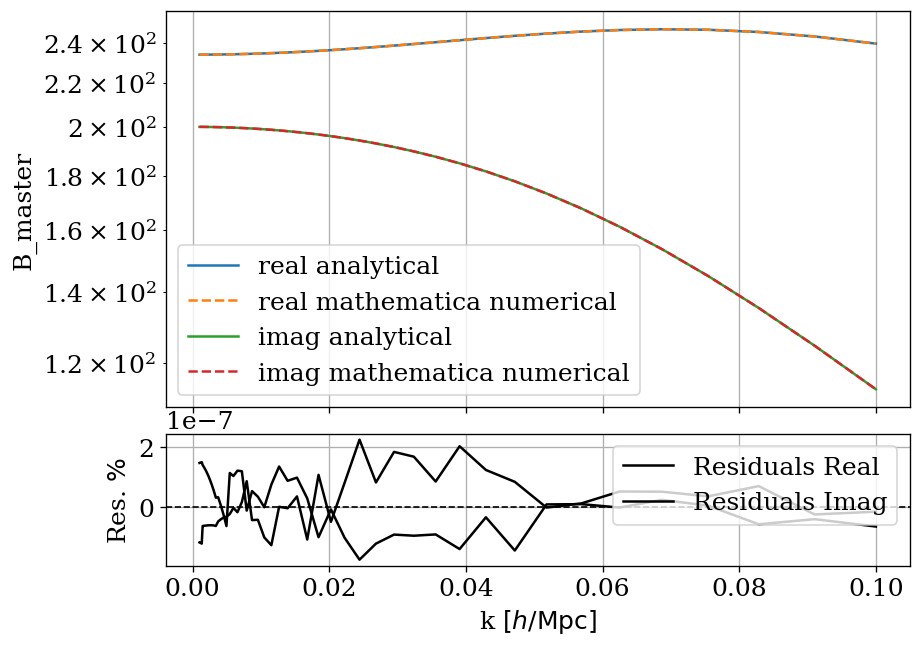

In [6]:

B_master_arr = np.zeros(k_size, dtype=complex)

M1_idx = 2
M2_idx = 4

# Fill the array using the CLASS implementation
for idx, k_in in enumerate(k):
    B_master_arr[idx] = LambdaCDM.get_B_master(k_in**2, M_n[M1_idx], M_n[M2_idx])

# read Mathematica file
B_master_mathematica = np.array(pd.read_csv(dir+"/B_master_integral/B_master_mathematica.csv", names=["k", "Real", "Imag"]))
k_math = B_master_mathematica[:,0]
B_math_real = B_master_mathematica[:,1]
B_math_imag = B_master_mathematica[:,2]


x1 = k/h
x2 = k_math/h
y1real = B_master_arr.real
y1imag = B_master_arr.imag
y2real = B_math_real
y2imag = B_math_imag
ylabel = "B_master"

compare_integrals(x1, x2, y1real, y1imag, y2real, y2imag, ylabel)

# $\text{Tad}_\text{master}$

In [7]:
M_idx = 3

n_size = 3
n_arr = np.arange(1, n_size+1)
d = 4

Tad_master_arr              = np.zeros(n_size, dtype=complex)
Tad_master_numerical_arr    = np.zeros(n_size, dtype=complex)


for idx, n in enumerate(n_arr):
    Tad_master_arr[idx]              = LambdaCDM.get_Tad_master(n, d, M_n[M_idx])



factor= 0.9999999999998075 1.0000000000001805


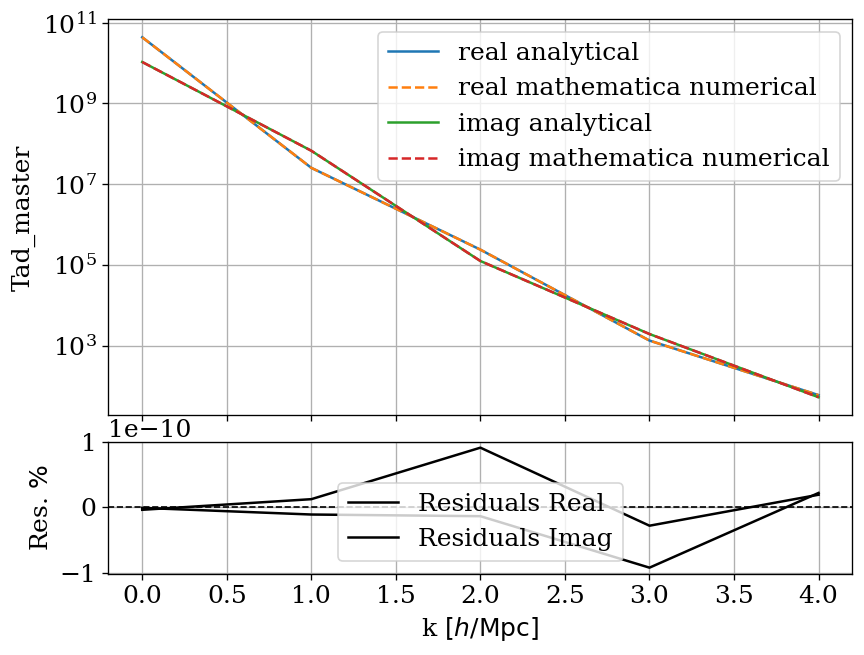

In [8]:
from math import gamma

M_idx   = 2

d       = 6
n_min   = 0
n_max   = d-2
n_arr   = np.arange(n_min, n_max+1)

Tad_master_arr = np.zeros(1+n_max-n_min, dtype=complex)


# Fill the array using the CLASS implementation
for idx, n in enumerate(n_arr):
    Tad_master_arr[idx] = LambdaCDM.get_Tad_master(n, d, M_n[M_idx])
    # Tad_master_arr[idx] = 2*np.pi * M_n[M_idx]**(n+1.5-d) * gamma(n+1.5)*gamma(d-n-1.5)/gamma(d)

# read Mathematica file
Tad_master_mathematica = np.array(pd.read_csv(dir+"/Tad_master_integral/Tad_master_mathematica.csv", names=["n", "Real", "Imag"]))
n_math = Tad_master_mathematica[:,0]
Tad_math_real = Tad_master_mathematica[:,1]
Tad_math_imag = Tad_master_mathematica[:,2]


x1 = n_arr
x2 = n_math
y1real = Tad_master_arr.real
y1imag = Tad_master_arr.imag
y2real = Tad_math_real
y2imag = Tad_math_imag
ylabel = "Tad_master"

compare_integrals(x1, x2, y1real, y1imag, y2real, y2imag, ylabel)

# $T_{master}$

In [9]:
# TODO

# $\text{Tad}_\text{var}$

factor= 0.9999999989187651 0.9999999997947593


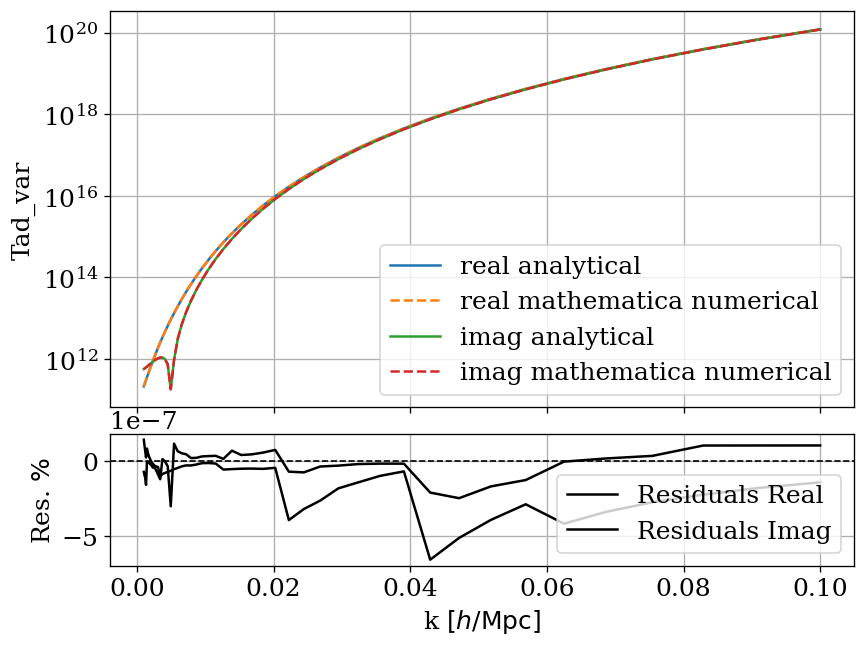

In [10]:
Tad_var_arr = np.zeros(k_size, dtype=complex)

M_idx = 4
n = 3
d = 7

# Fill the array using the CLASS implementation
for idx, k_in in enumerate(k):
    Tad_var_arr[idx] = LambdaCDM.get_Tad_var(n, d, k_in**2, M_n[M_idx])

# read Mathematica file
Tad_var_mathematica = np.array(pd.read_csv(dir+"/Tad_var_integral/Tad_var_mathematica.csv", names=["n", "Real", "Imag"]))
k_math = Tad_var_mathematica[:,0]
Tad_var_math_real = Tad_var_mathematica[:,1]
Tad_var_math_imag = Tad_var_mathematica[:,2]


x1 = k/h
x2 = k_math/h
y1real = Tad_var_arr.real
y1imag = Tad_var_arr.imag
y2real = Tad_var_math_real
y2imag = Tad_var_math_imag
ylabel = "Tad_var"

compare_integrals(x1, x2, y1real, y1imag, y2real, y2imag, ylabel)

# massive_num

factor= 1.0000000006464858 1.0000000001678793


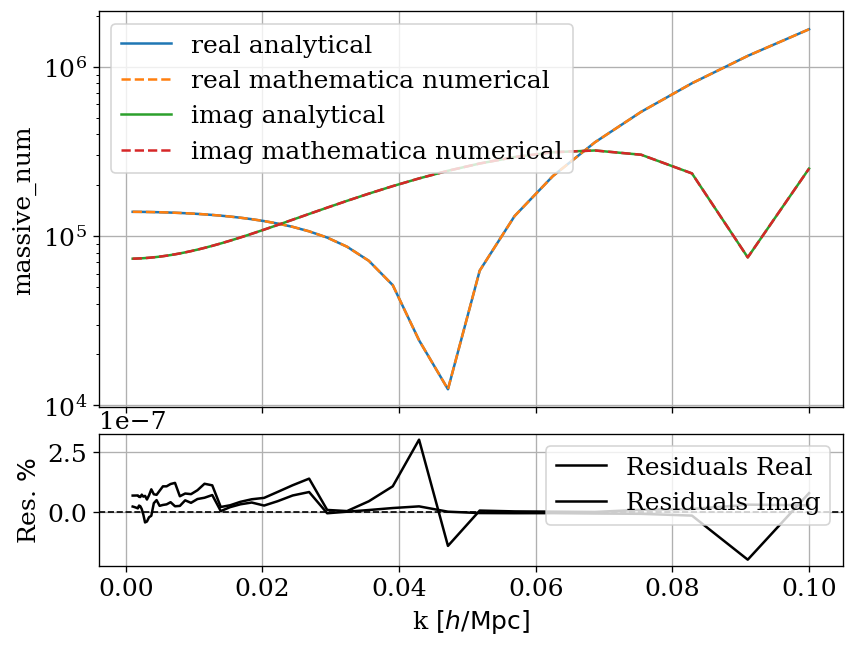

In [11]:
massive_num_arr = np.zeros(k_size, dtype=complex)

M1_idx = 4
M2_idx = 2
n = 3
d = 7

# Fill the array using the CLASS implementation
for idx, k_in in enumerate(k):
    massive_num_arr[idx] = LambdaCDM.get_massive_num(n, d, k_in**2, M_n[M1_idx], M_n[M2_idx])

# read Mathematica file
massive_num_mathematica = np.array(pd.read_csv(dir+"/massive_num_integral/massive_num_mathematica.csv", names=["n", "Real", "Imag"]))
k_math = massive_num_mathematica[:,0]
massive_num_math_real = massive_num_mathematica[:,1]
massive_num_math_imag = massive_num_mathematica[:,2]


x1 = k/h
x2 = k_math/h
y1real = massive_num_arr.real
y1imag = massive_num_arr.imag
y2real = massive_num_math_real
y2imag = massive_num_math_imag
ylabel = "massive_num"

compare_integrals(x1, x2, y1real, y1imag, y2real, y2imag, ylabel)

# B_recursion

factor= 0.9999999977979526 1.000000000298311


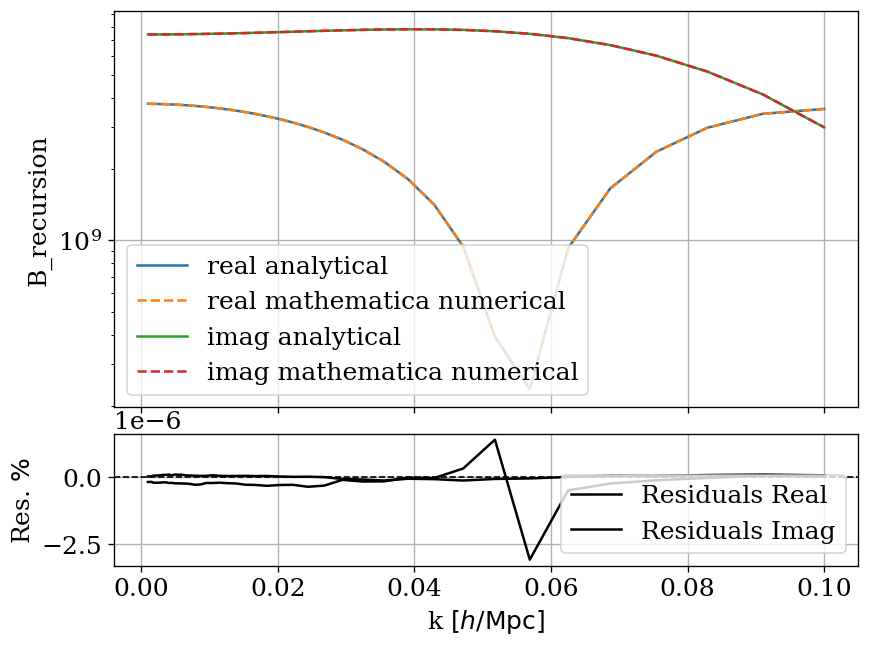

In [ ]:
# There are many different cases and some of them yield diverging integrals. Check that for allowed values of d1 and d2, the divergent cases are never encountered
k_min = 1e-3*h
k_max = 1e-1*h

k = np.logspace(np.log10(k_min),np.log10(k_max), k_size)
B_recursion_arr = np.zeros(k_size, dtype=complex)

M1_idx = 2
M2_idx = 3
d1 = 2
d2 = 3

# Fill the array using the CLASS implementation
for idx, k_in in enumerate(k):
    B_recursion_arr[idx] = LambdaCDM.get_B_recursion(d1, d2, k_in**2, M_n[M1_idx], M_n[M2_idx])

# read Mathematica file
B_recursion_mathematica = np.array(pd.read_csv(dir+"/B_recursion_integral/B_recursion_mathematica.csv", names=["n", "Real", "Imag"]))
k_math = B_recursion_mathematica[:,0]
B_recursion_math_real = B_recursion_mathematica[:,1]
B_recursion_math_imag = B_recursion_mathematica[:,2]


x1 = k/h
x2 = k_math/h
y1real = B_recursion_arr.real
y1imag = B_recursion_arr.imag
y2real = B_recursion_math_real
y2imag = B_recursion_math_imag
ylabel = "B_recursion"

compare_integrals(x1, x2, y1real, y1imag, y2real, y2imag, ylabel)

# tensor_red_one

# tensor_red_two